In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


import kagglehub

path = kagglehub.dataset_download("gamzegedik044/bitcoin-daily-price-20152025")

print("Path to dataset files:", path)

# Load the CSV, skipping the problematic first data row (index 0 in raw data, which has NaN in 'Date' and string values)
df = pd.read_csv(f'{path}/bitcoin_price_2015_2025.csv', skiprows=[1])

# The actual column names are correctly inferred after skipping the first row

print(df.head())
print(df.info())
print(df.describe())

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

Using Colab cache for faster access to the 'bitcoin-daily-price-20152025' dataset.
Path to dataset files: /kaggle/input/bitcoin-daily-price-20152025
         Date       Close        High         Low        Open    Volume
0  2015-01-01  314.248993  320.434998  314.002991  320.434998   8036550
1  2015-01-02  315.032013  315.838989  313.565002  314.079010   7860650
2  2015-01-03  281.082001  315.149994  281.082001  314.846008  33054400
3  2015-01-04  264.195007  287.230011  257.612000  281.145996  55629100
4  2015-01-05  274.473999  278.341003  265.084015  265.084015  43962800
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3912 entries, 0 to 3911
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3912 non-null   object 
 1   Close   3912 non-null   float64
 2   High    3912 non-null   float64
 3   Low     3912 non-null   float64
 4   Open    3912 non-null   float64
 5   Volume  3912 non-null   int64  
dtypes: float64(4

In [112]:
# Convert 'Volume','High',"Low",'Open' and 'Close' to numeric, removing commas
df['Volume'] = df['Volume'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

In [113]:
# Create some simple features
df['HL_diff'] = df['High'] - df['Low']
df['OC_diff'] = df['Open'] - df['Close']
df['Daily_return'] = df['Close'].pct_change(fill_method=None)

# Forward‐fill or drop NA rows
df = df.dropna()

In [114]:
# Define features (X) and target (y) — predict next‐day Close price
X = df[['Open', 'High', 'Low', 'Volume', 'HL_diff', 'OC_diff', 'Daily_return']]
y = df['Close'].shift(-1)

combined_df = pd.concat([X, y], axis=1).dropna()

X = combined_df.iloc[:, :-1]
y = combined_df.iloc[:, -1]

In [115]:
# 4. Train/test split: Train on data before 2025, test on data from 2025

split_point_y_index = pd.to_datetime('2025-01-01')

y_train = y[y.index < split_point_y_index]
y_test = y[y.index >= split_point_y_index]

X_train = X[X.index < split_point_y_index]
X_test = X[X.index >= split_point_y_index]

# 5. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [116]:
# 6. Model training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 7. Predictions
y_pred = model.predict(X_test_scaled)

In [117]:
# 8. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}")
print(f"R2 score: {r2:.4f}")

MSE: 4471546.3973
R2 score: 0.9667


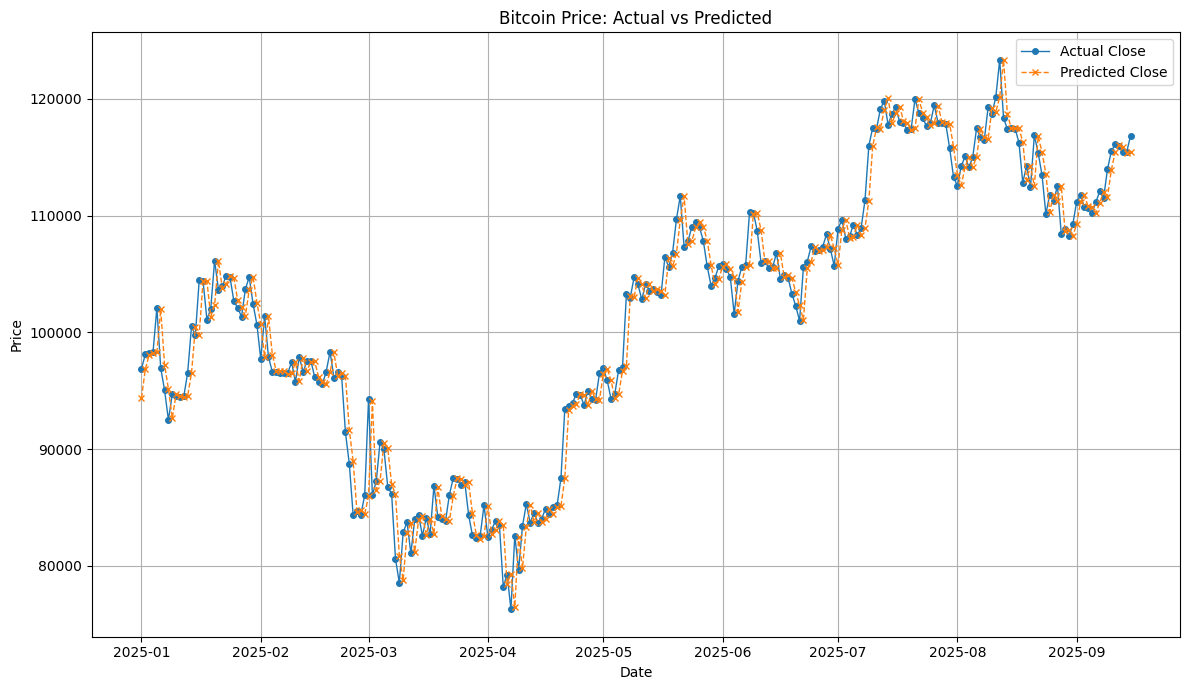

In [118]:
# 9. Plot actual vs predicted
plt.figure(figsize=(12, 7))
plt.plot(y_test.index, y_test.values, label='Actual Close', marker='o', markersize=4, linestyle='-', linewidth=1)
plt.plot(y_test.index, y_pred, label='Predicted Close', marker='x', markersize=4, linestyle='--', linewidth=1)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Bitcoin Price: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()